# Exploración del Entorno CartPole-v1

Este notebook contiene la exploración inicial del entorno CartPole-v1 de Gymnasium, necesaria para comprender el espacio de observaciones y diseñar una estrategia de discretización adecuada para la implementación de Q-Learning.

## Importación de librerías

In [38]:
import gymnasium as gym
import numpy as np
import random

In [39]:
# Inicializar el entorno en modo sin visualización para análisis
env = gym.make('CartPole-v1', render_mode=None)

## Análisis del espacio de observaciones

El espacio de observaciones de CartPole-v1 es continuo y contiene 4 variables.

In [40]:
print("Espacio de observaciones:", env.observation_space)
print("Límites inferiores:", env.observation_space.low)
print("Límites superiores:", env.observation_space.high)

Espacio de observaciones: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Límites inferiores: [-4.8               -inf -0.41887903        -inf]
Límites superiores: [4.8               inf 0.41887903        inf]


## Análisis del espacio de acciones

El espacio de acciones determina los movimientos que puede realizar el agente.

In [41]:
print("Espacio de acciones:", env.action_space)
print("Número de acciones:", env.action_space.n)
print("Acción 0: Empujar el carro hacia la izquierda")
print("Acción 1: Empujar el carro hacia la derecha")

Espacio de acciones: Discrete(2)
Número de acciones: 2
Acción 0: Empujar el carro hacia la izquierda
Acción 1: Empujar el carro hacia la derecha


## Exploración de rangos reales de las variables

Dado que los límites teóricos del espacio de observaciones incluyen infinitos, es necesario ejecutar episodios aleatorios para determinar los rangos reales que toman las variables durante el juego. Esta información será fundamental para diseñar una discretización efectiva.

In [42]:
# Ejecutar episodios aleatorios para observar los rangos reales
num_episodes = 100
observations = []

for episode in range(num_episodes):
    obs, _ = env.reset()
    done = False
    
    while not done:
        observations.append(obs)
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

observations = np.array(observations)

# Calcular estadísticas de cada variable
variables = ['Posición del carro', 'Velocidad del carro', 'Ángulo del poste', 'Velocidad angular del poste']
print("Estadísticas de las variables observadas en {} episodios aleatorios:\n".format(num_episodes))

for i, var_name in enumerate(variables):
    print(f"{var_name}:")
    print(f"  Mínimo: {observations[:, i].min():.4f}")
    print(f"  Máximo: {observations[:, i].max():.4f}")
    print(f"  Media: {observations[:, i].mean():.4f}")
    print(f"  Desviación estándar: {observations[:, i].std():.4f}")
    print()

Estadísticas de las variables observadas en 100 episodios aleatorios:

Posición del carro:
  Mínimo: -0.4437
  Máximo: 0.3209
  Media: -0.0032
  Desviación estándar: 0.0760

Velocidad del carro:
  Mínimo: -1.7788
  Máximo: 1.8829
  Media: 0.0122
  Desviación estándar: 0.5029

Ángulo del poste:
  Mínimo: -0.2091
  Máximo: 0.2094
  Media: 0.0005
  Desviación estándar: 0.0926

Velocidad angular del poste:
  Mínimo: -2.4731
  Máximo: 2.5807
  Media: -0.0082
  Desviación estándar: 0.7649



## Análisis de criticidad de las variables

Según la documentación de CartPole-v1, el episodio termina cuando:
- La posición del carro excede ±2.4 unidades
- El ángulo del poste excede ±12 grados (≈ ±0.2095 radianes)

Las variables relacionadas con el ángulo del poste son críticas para mantener el equilibrio, mientras que la posición del carro tiene un margen más amplio.

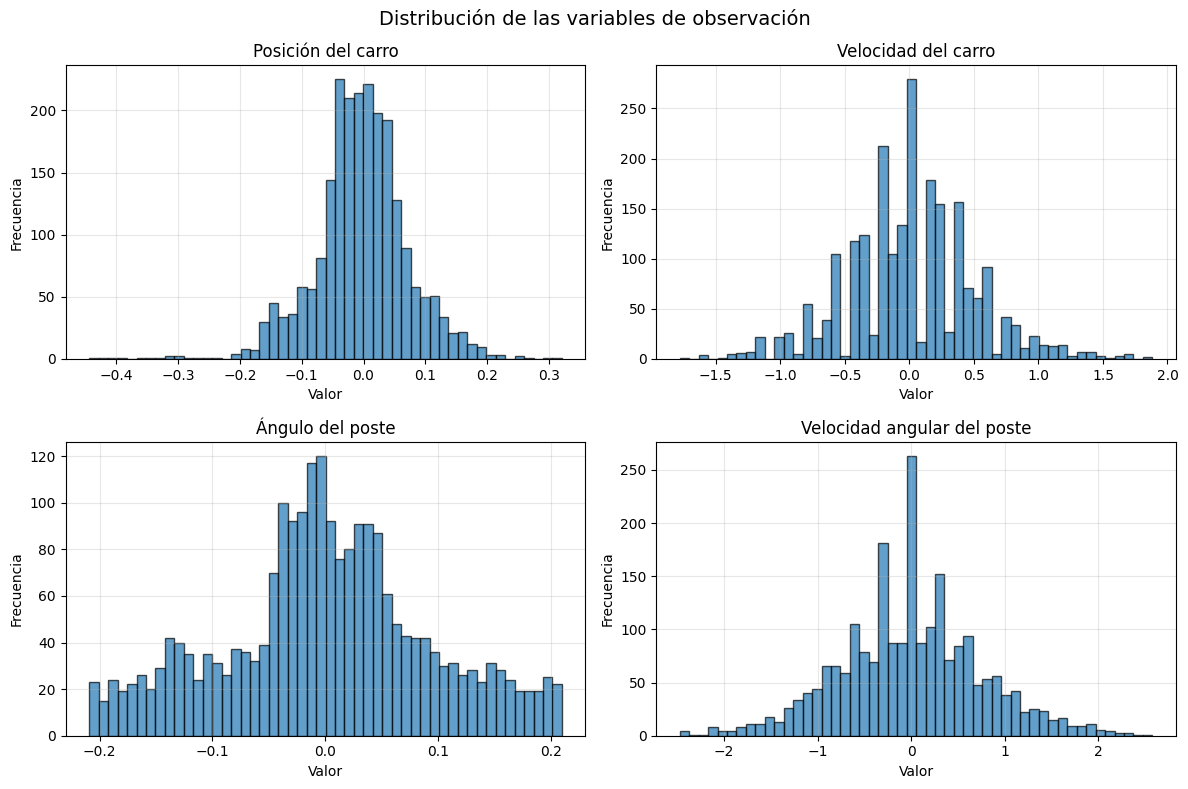

In [43]:
# Visualizar distribución de las variables
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de las variables de observación', fontsize=14)

for i, (var_name, ax) in enumerate(zip(variables, axes.flatten())):
    ax.hist(observations[:, i], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(var_name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# Determinar rangos prácticos para discretización
# Usaremos percentiles para evitar valores extremos que rara vez ocurren

print("Rangos recomendados para discretización (basados en percentiles 1-99):\n")

for i, var_name in enumerate(variables):
    p1 = np.percentile(observations[:, i], 1)
    p99 = np.percentile(observations[:, i], 99)
    print(f"{var_name}:")
    print(f"  Rango sugerido: [{p1:.4f}, {p99:.4f}]")
    print()

Rangos recomendados para discretización (basados en percentiles 1-99):

Posición del carro:
  Rango sugerido: [-0.1937, 0.1792]

Velocidad del carro:
  Rango sugerido: [-1.2011, 1.3268]

Ángulo del poste:
  Rango sugerido: [-0.2005, 0.2003]

Velocidad angular del poste:
  Rango sugerido: [-1.8617, 1.9338]



## Conclusiones de la exploración

Los resultados de esta exploración nos permiten establecer:

1. **Variables críticas**: Ángulo del poste y velocidad angular del poste requieren mayor resolución en la discretización debido a su impacto directo en el equilibrio.

2. **Variables no críticas**: Posición y velocidad del carro pueden discretizarse con menos bins sin perder información esencial.

3. **Estrategia de discretización**: Se implementarán dos versiones:
   - Discretización gruesa: 3 bins para variables no críticas, 6 bins para variables críticas
   - Discretización fina: 6 bins para variables no críticas, 12 bins para variables críticas

## Definición de rangos óptimos para discretización

Basándonos en el análisis realizado, los límites de terminación del entorno y las mejores prácticas, se establecen los siguientes rangos para la discretización:

In [45]:
# Definición de rangos para discretización
# Estos rangos serán utilizados en las implementaciones de Q-Learning

# Variables NO CRÍTICAS (menor impacto en terminación del episodio)
cart_position_range = (-2.4, 2.4)        # Límite exacto de terminación del entorno
cart_velocity_range = (-3.0, 3.0)        # Rango amplio que cubre comportamiento de políticas entrenadas

# Variables CRÍTICAS (impacto directo en equilibrio del poste)
pole_angle_range = (-0.21, 0.21)         # Límite exacto de terminación (±12 grados)
pole_angular_velocity_range = (-3.5, 3.5)  # Rango que captura estados de alta velocidad angular

print("Rangos definidos para discretización:\n")
print(f"Posición del carro: {cart_position_range}")
print(f"Velocidad del carro: {cart_velocity_range}")
print(f"Ángulo del poste: {pole_angle_range}")
print(f"Velocidad angular del poste: {pole_angular_velocity_range}")

Rangos definidos para discretización:

Posición del carro: (-2.4, 2.4)
Velocidad del carro: (-3.0, 3.0)
Ángulo del poste: (-0.21, 0.21)
Velocidad angular del poste: (-3.5, 3.5)


### Justificación de los rangos seleccionados

**Posición del carro** `[-2.4, 2.4]`:
- Corresponde al límite exacto de terminación del entorno
- Aunque en episodios aleatorios no se exploró completamente, un agente entrenado necesitará acceder a todo el rango

**Velocidad del carro** `[-3.0, 3.0]`:
- Rango observado en episodios aleatorios: aproximadamente ±1.9
- Se amplía para capturar velocidades mayores que puede desarrollar un agente entrenado
- Valor conservador que equilibra cobertura y eficiencia de la tabla Q

**Ángulo del poste** `[-0.21, 0.21]` rad (±12°):
- Variable más crítica: el episodio termina si se excede este límite
- Usar el límite exacto asegura que todos los estados válidos estén representados
- Requiere mayor resolución en la discretización

**Velocidad angular del poste** `[-3.5, 3.5]` rad/s:
- Segunda variable crítica: determina si el poste se recupera o continúa cayendo
- Rango observado: aproximadamente ±2.5
- Se amplía para capturar situaciones límite donde el agente debe realizar correcciones agresivas
- Requiere mayor resolución en la discretización

# Implementación de Discretización

En esta sección se implementan dos estrategias de discretización para convertir el espacio de observaciones continuo en estados discretos que permitan la aplicación de Q-Learning.

## Discretización Gruesa

Esta discretización utiliza menor resolución para crear un espacio de estados más compacto:
- Variables no críticas (posición y velocidad del carro): 3 bins
- Variables críticas (ángulo y velocidad angular del poste): 6 bins
- Espacio de estados total: 3 × 3 × 6 × 6 = 324 estados

In [46]:
# Crear bins para discretización gruesa
n_bins_cart_pos_coarse = 3
n_bins_cart_vel_coarse = 3
n_bins_pole_angle_coarse = 6
n_bins_pole_ang_vel_coarse = 6

# Generar los límites de los bins usando linspace
cart_pos_bins_coarse = np.linspace(cart_position_range[0], cart_position_range[1], n_bins_cart_pos_coarse + 1)
cart_vel_bins_coarse = np.linspace(cart_velocity_range[0], cart_velocity_range[1], n_bins_cart_vel_coarse + 1)
pole_angle_bins_coarse = np.linspace(pole_angle_range[0], pole_angle_range[1], n_bins_pole_angle_coarse + 1)
pole_ang_vel_bins_coarse = np.linspace(pole_angular_velocity_range[0], pole_angular_velocity_range[1], n_bins_pole_ang_vel_coarse + 1)

print("Discretización Gruesa:")
print(f"Total de estados: {n_bins_cart_pos_coarse * n_bins_cart_vel_coarse * n_bins_pole_angle_coarse * n_bins_pole_ang_vel_coarse}")
print(f"\nBins por variable:")
print(f"  Posición del carro: {n_bins_cart_pos_coarse} bins")
print(f"  Velocidad del carro: {n_bins_cart_vel_coarse} bins")
print(f"  Ángulo del poste: {n_bins_pole_angle_coarse} bins")
print(f"  Velocidad angular del poste: {n_bins_pole_ang_vel_coarse} bins")

Discretización Gruesa:
Total de estados: 324

Bins por variable:
  Posición del carro: 3 bins
  Velocidad del carro: 3 bins
  Ángulo del poste: 6 bins
  Velocidad angular del poste: 6 bins


In [47]:
# Función para discretizar observaciones (versión gruesa)
def discretize_observation_coarse(observation):
    """
    Convierte una observación continua en un estado discreto usando discretización gruesa.
    
    Args:
        observation: Array de 4 elementos con [posición, velocidad, ángulo, velocidad_angular]
    
    Returns:
        Tupla de 4 enteros representando el estado discreto
    """
    cart_pos, cart_vel, pole_angle, pole_ang_vel = observation
    
    # Usar digitize para encontrar el bin correspondiente (restamos 1 para indexar desde 0)
    cart_pos_idx = np.digitize(cart_pos, cart_pos_bins_coarse[1:-1])
    cart_vel_idx = np.digitize(cart_vel, cart_vel_bins_coarse[1:-1])
    pole_angle_idx = np.digitize(pole_angle, pole_angle_bins_coarse[1:-1])
    pole_ang_vel_idx = np.digitize(pole_ang_vel, pole_ang_vel_bins_coarse[1:-1])
    
    return (cart_pos_idx, cart_vel_idx, pole_angle_idx, pole_ang_vel_idx)

In [48]:
# Verificar funcionamiento de la discretización gruesa
test_obs, _ = env.reset()
print("Observación continua de prueba:")
print(f"  Posición: {test_obs[0]:.4f}")
print(f"  Velocidad: {test_obs[1]:.4f}")
print(f"  Ángulo: {test_obs[2]:.4f}")
print(f"  Velocidad angular: {test_obs[3]:.4f}")

test_state = discretize_observation_coarse(test_obs)
print(f"\nEstado discreto resultante: {test_state}")
print(f"Índices válidos: cart_pos[0-{n_bins_cart_pos_coarse-1}], cart_vel[0-{n_bins_cart_vel_coarse-1}], pole_angle[0-{n_bins_pole_angle_coarse-1}], pole_ang_vel[0-{n_bins_pole_ang_vel_coarse-1}]")

Observación continua de prueba:
  Posición: -0.0444
  Velocidad: 0.0187
  Ángulo: -0.0360
  Velocidad angular: 0.0014

Estado discreto resultante: (np.int64(1), np.int64(1), np.int64(2), np.int64(3))
Índices válidos: cart_pos[0-2], cart_vel[0-2], pole_angle[0-5], pole_ang_vel[0-5]


## Discretización Fina

Esta discretización utiliza mayor resolución para capturar más detalles del espacio de estados:
- Variables no críticas (posición y velocidad del carro): 6 bins
- Variables críticas (ángulo y velocidad angular del poste): 12 bins
- Espacio de estados total: 6 × 6 × 12 × 12 = 5,184 estados

In [49]:
# Crear bins para discretización fina
n_bins_cart_pos_fine = 6
n_bins_cart_vel_fine = 6
n_bins_pole_angle_fine = 12
n_bins_pole_ang_vel_fine = 12

# Generar los límites de los bins usando linspace
cart_pos_bins_fine = np.linspace(cart_position_range[0], cart_position_range[1], n_bins_cart_pos_fine + 1)
cart_vel_bins_fine = np.linspace(cart_velocity_range[0], cart_velocity_range[1], n_bins_cart_vel_fine + 1)
pole_angle_bins_fine = np.linspace(pole_angle_range[0], pole_angle_range[1], n_bins_pole_angle_fine + 1)
pole_ang_vel_bins_fine = np.linspace(pole_angular_velocity_range[0], pole_angular_velocity_range[1], n_bins_pole_ang_vel_fine + 1)

print("Discretización Fina:")
print(f"Total de estados: {n_bins_cart_pos_fine * n_bins_cart_vel_fine * n_bins_pole_angle_fine * n_bins_pole_ang_vel_fine}")
print(f"\nBins por variable:")
print(f"  Posición del carro: {n_bins_cart_pos_fine} bins")
print(f"  Velocidad del carro: {n_bins_cart_vel_fine} bins")
print(f"  Ángulo del poste: {n_bins_pole_angle_fine} bins")
print(f"  Velocidad angular del poste: {n_bins_pole_ang_vel_fine} bins")

Discretización Fina:
Total de estados: 5184

Bins por variable:
  Posición del carro: 6 bins
  Velocidad del carro: 6 bins
  Ángulo del poste: 12 bins
  Velocidad angular del poste: 12 bins


In [50]:
# Función para discretizar observaciones (versión fina)
def discretize_observation_fine(observation):
    """
    Convierte una observación continua en un estado discreto usando discretización fina.
    
    Args:
        observation: Array de 4 elementos con [posición, velocidad, ángulo, velocidad_angular]
    
    Returns:
        Tupla de 4 enteros representando el estado discreto
    """
    cart_pos, cart_vel, pole_angle, pole_ang_vel = observation
    
    # Usar digitize para encontrar el bin correspondiente (restamos 1 para indexar desde 0)
    cart_pos_idx = np.digitize(cart_pos, cart_pos_bins_fine[1:-1])
    cart_vel_idx = np.digitize(cart_vel, cart_vel_bins_fine[1:-1])
    pole_angle_idx = np.digitize(pole_angle, pole_angle_bins_fine[1:-1])
    pole_ang_vel_idx = np.digitize(pole_ang_vel, pole_ang_vel_bins_fine[1:-1])
    
    return (cart_pos_idx, cart_vel_idx, pole_angle_idx, pole_ang_vel_idx)

In [51]:
# Verificar funcionamiento de la discretización fina
test_state_fine = discretize_observation_fine(test_obs)
print("Misma observación continua de prueba:")
print(f"  Posición: {test_obs[0]:.4f}")
print(f"  Velocidad: {test_obs[1]:.4f}")
print(f"  Ángulo: {test_obs[2]:.4f}")
print(f"  Velocidad angular: {test_obs[3]:.4f}")

print(f"\nEstado discreto resultante: {test_state_fine}")
print(f"Índices válidos: cart_pos[0-{n_bins_cart_pos_fine-1}], cart_vel[0-{n_bins_cart_vel_fine-1}], pole_angle[0-{n_bins_pole_angle_fine-1}], pole_ang_vel[0-{n_bins_pole_ang_vel_fine-1}]")

Misma observación continua de prueba:
  Posición: -0.0444
  Velocidad: 0.0187
  Ángulo: -0.0360
  Velocidad angular: 0.0014

Estado discreto resultante: (np.int64(2), np.int64(3), np.int64(4), np.int64(6))
Índices válidos: cart_pos[0-5], cart_vel[0-5], pole_angle[0-11], pole_ang_vel[0-11]


## Comparación de las Discretizaciones

La discretización gruesa ofrece un espacio de estados 16 veces más pequeño (324 vs 5,184), lo que implica:

**Ventajas de la discretización gruesa:**
- Convergencia más rápida durante el entrenamiento
- Menor uso de memoria
- Más adecuada para exploración inicial

**Ventajas de la discretización fina:**
- Mayor precisión en la representación de estados
- Puede capturar diferencias sutiles importantes para el control
- Potencialmente mejor performance final

Ambas discretizaciones priorizan las variables críticas (ángulo y velocidad angular del poste) con el doble de bins que las variables no críticas.

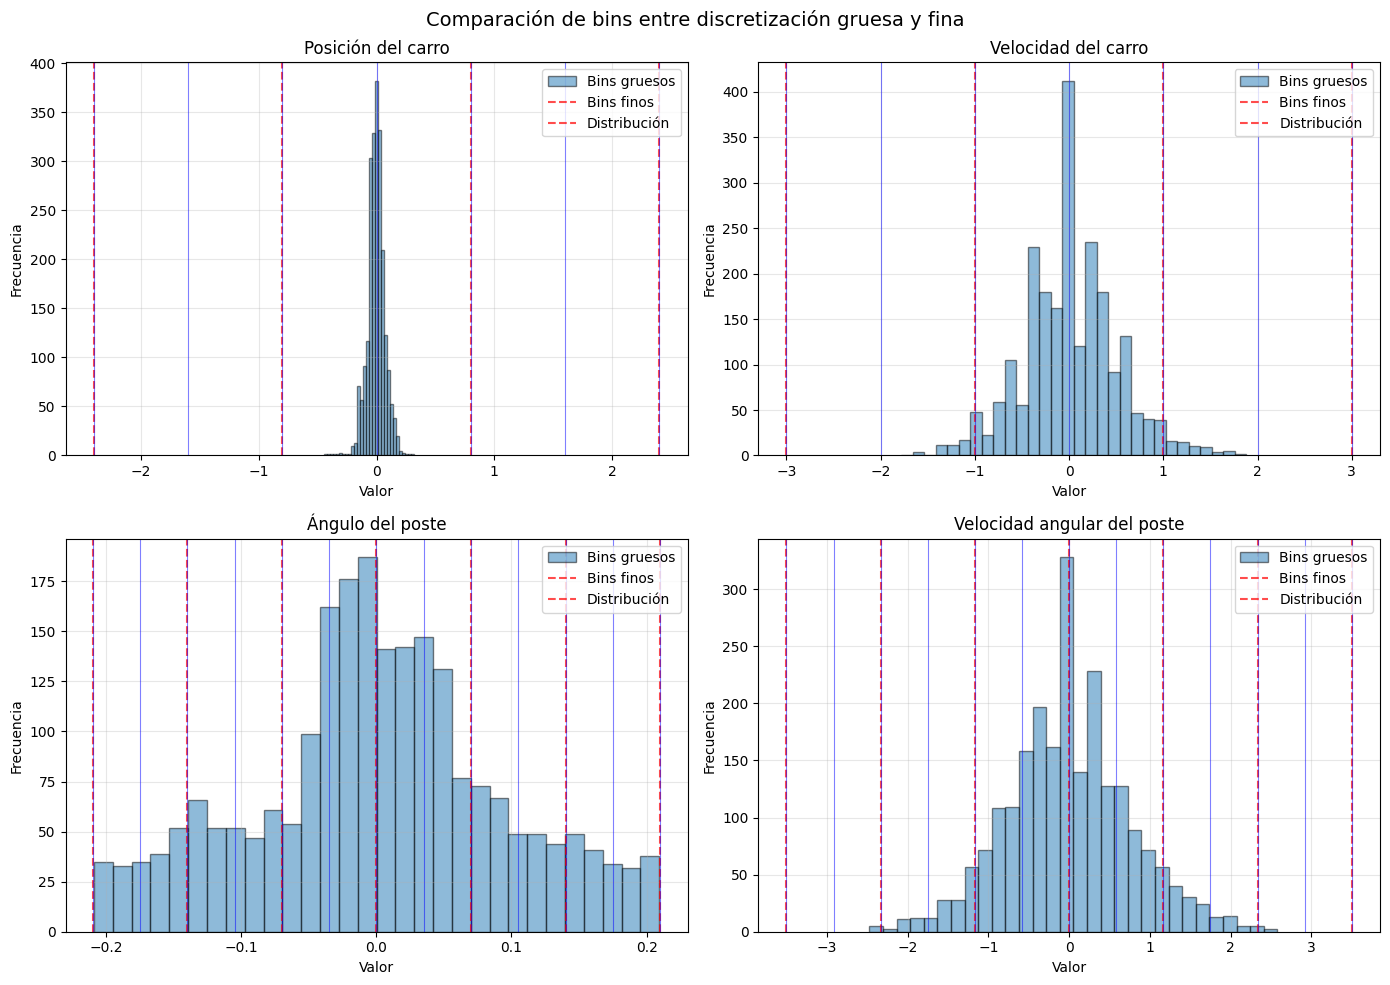

  Líneas rojas discontinuas: Límites de bins en discretización gruesa
  Líneas azules continuas: Límites de bins en discretización fina


In [52]:
# Visualizar diferencia en granularidad entre discretizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de bins entre discretización gruesa y fina', fontsize=14)

bins_coarse = [cart_pos_bins_coarse, cart_vel_bins_coarse, pole_angle_bins_coarse, pole_ang_vel_bins_coarse]
bins_fine = [cart_pos_bins_fine, cart_vel_bins_fine, pole_angle_bins_fine, pole_ang_vel_bins_fine]

for i, (var_name, ax) in enumerate(zip(variables, axes.flatten())):
    # Histograma de las observaciones
    ax.hist(observations[:, i], bins=30, alpha=0.5, edgecolor='black', label='Distribución observada')
    
    # Líneas verticales para bins gruesos
    for bin_edge in bins_coarse[i]:
        ax.axvline(bin_edge, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Líneas verticales para bins finos
    for bin_edge in bins_fine[i]:
        ax.axvline(bin_edge, color='blue', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.set_title(var_name)
    ax.grid(True, alpha=0.3)
    ax.legend(['Bins gruesos', 'Bins finos', 'Distribución'], loc='upper right')

plt.tight_layout()
plt.show()

print("  Líneas rojas discontinuas: Límites de bins en discretización gruesa")
print("  Líneas azules continuas: Límites de bins en discretización fina")

# Implementación de Q-Learning

En esta sección se implementa el algoritmo de Q-Learning para entrenar un agente que aprenda a mantener el equilibrio del poste sobre el carro.

## Inicialización de la tabla Q

La tabla Q almacena el valor esperado de cada par estado-acción. Se inicializa con ceros y se actualiza durante el entrenamiento.

In [53]:
# Inicializar tabla Q para discretización gruesa
# Dimensiones: (cart_pos, cart_vel, pole_angle, pole_ang_vel, acciones)
Q_table_coarse = np.zeros((
    n_bins_cart_pos_coarse,
    n_bins_cart_vel_coarse,
    n_bins_pole_angle_coarse,
    n_bins_pole_ang_vel_coarse,
    env.action_space.n
))

print(f"Tabla Q inicializada con forma: {Q_table_coarse.shape}")
print(f"Total de valores en la tabla Q: {Q_table_coarse.size}")
print(f"Memoria utilizada: {Q_table_coarse.nbytes / 1024:.2f} KB")

Tabla Q inicializada con forma: (3, 3, 6, 6, 2)
Total de valores en la tabla Q: 648
Memoria utilizada: 5.06 KB


## Funciones de política

Implementación de las políticas de selección de acciones necesarias para el algoritmo.

In [54]:
def epsilon_greedy_policy(state, Q_table, epsilon):
    """
    Selecciona una acción usando la política epsilon-greedy.
    Con probabilidad epsilon explora (acción aleatoria), 
    con probabilidad (1-epsilon) explota (mejor acción conocida).
    
    Args:
        state: Estado discreto actual (tupla de índices)
        Q_table: Tabla Q con los valores de estado-acción
        epsilon: Probabilidad de exploración
    
    Returns:
        Acción seleccionada (0 o 1)
    """
    if np.random.random() < epsilon:
        # Exploración: acción aleatoria
        return env.action_space.sample()
    else:
        # Explotación: mejor acción según Q
        return np.argmax(Q_table[state])


def greedy_policy(state, Q_table):
    """
    Selecciona la mejor acción según los valores actuales de Q.
    Se utiliza durante la evaluación del agente entrenado.
    
    Args:
        state: Estado discreto actual (tupla de índices)
        Q_table: Tabla Q con los valores de estado-acción
    
    Returns:
        Mejor acción (0 o 1)
    """
    return np.argmax(Q_table[state])

## Algoritmo de Q-Learning

Implementación del algoritmo de Q-Learning con la ecuación de actualización:

$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

Donde:
- $\alpha$ es la tasa de aprendizaje (learning rate)
- $\gamma$ es el factor de descuento (discount factor)
- $r$ es la recompensa obtenida
- $s$ es el estado actual
- $s'$ es el estado siguiente
- $a$ es la acción tomada

In [55]:
def q_learning_train(env, Q_table, discretize_fn, n_episodes, alpha, gamma, 
                     epsilon_start, epsilon_end, epsilon_decay_type='linear'):
    """
    Entrena un agente usando Q-Learning.
    
    Args:
        env: Entorno de Gymnasium
        Q_table: Tabla Q a actualizar
        discretize_fn: Función para discretizar observaciones
        n_episodes: Número de episodios de entrenamiento
        alpha: Tasa de aprendizaje
        gamma: Factor de descuento
        epsilon_start: Epsilon inicial para exploración
        epsilon_end: Epsilon final para exploración
        epsilon_decay_type: Tipo de decaimiento ('linear' o 'exponential')
    
    Returns:
        rewards_history: Lista con recompensas totales por episodio
        steps_history: Lista con pasos por episodio
    """
    rewards_history = []
    steps_history = []
    
    for episode in range(n_episodes):
        # Calcular epsilon para este episodio
        if epsilon_decay_type == 'linear':
            epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / n_episodes)
        else:  # exponential
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-episode / (n_episodes * 0.3))
        
        # Inicializar episodio
        obs, _ = env.reset()
        state = discretize_fn(obs)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Seleccionar acción usando política epsilon-greedy
            action = epsilon_greedy_policy(state, Q_table, epsilon)
            
            # Ejecutar acción
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize_fn(next_obs)
            
            # Actualizar Q-table usando la ecuación de Q-Learning
            best_next_action = np.argmax(Q_table[next_state])
            td_target = reward + gamma * Q_table[next_state][best_next_action]
            td_error = td_target - Q_table[state][action]
            Q_table[state][action] += alpha * td_error
            
            # Actualizar estado
            state = next_state
            total_reward += reward
            steps += 1
        
        rewards_history.append(total_reward)
        steps_history.append(steps)
        
        # Mostrar progreso cada 100 episodios
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episodio {episode + 1}/{n_episodes}, "
                  f"Epsilon: {epsilon:.3f}, "
                  f"Recompensa promedio (últimos 100): {avg_reward:.2f}")
    
    return rewards_history, steps_history

## Entrenamiento inicial con hiperparámetros base

Se entrena un primer modelo con hiperparámetros conservadores para verificar que el algoritmo funciona correctamente.

In [56]:
# Hiperparámetros base para entrenamiento inicial
n_episodes_base = 1000
alpha_base = 0.1
gamma_base = 0.99
epsilon_start_base = 1.0
epsilon_end_base = 0.01

print("Iniciando entrenamiento con discretización gruesa...")
print(f"Hiperparámetros:")
print(f"  Episodios: {n_episodes_base}")
print(f"  Alpha (α): {alpha_base}")
print(f"  Gamma (γ): {gamma_base}")
print(f"  Epsilon inicial: {epsilon_start_base}")
print(f"  Epsilon final: {epsilon_end_base}")
print(f"  Decaimiento: lineal")
print()

Iniciando entrenamiento con discretización gruesa...
Hiperparámetros:
  Episodios: 1000
  Alpha (α): 0.1
  Gamma (γ): 0.99
  Epsilon inicial: 1.0
  Epsilon final: 0.01
  Decaimiento: lineal



In [57]:
# Entrenar el agente
import time
start_time = time.time()

rewards_base, steps_base = q_learning_train(
    env=env,
    Q_table=Q_table_coarse,
    discretize_fn=discretize_observation_coarse,
    n_episodes=n_episodes_base,
    alpha=alpha_base,
    gamma=gamma_base,
    epsilon_start=epsilon_start_base,
    epsilon_end=epsilon_end_base,
    epsilon_decay_type='linear'
)

training_time = time.time() - start_time
print(f"\nEntrenamiento completado en {training_time:.2f} segundos ({training_time/60:.2f} minutos)")

Episodio 100/1000, Epsilon: 0.902, Recompensa promedio (últimos 100): 26.01
Episodio 200/1000, Epsilon: 0.803, Recompensa promedio (últimos 100): 26.53
Episodio 300/1000, Epsilon: 0.704, Recompensa promedio (últimos 100): 32.87
Episodio 400/1000, Epsilon: 0.605, Recompensa promedio (últimos 100): 30.63
Episodio 500/1000, Epsilon: 0.506, Recompensa promedio (últimos 100): 41.25
Episodio 600/1000, Epsilon: 0.407, Recompensa promedio (últimos 100): 53.28
Episodio 700/1000, Epsilon: 0.308, Recompensa promedio (últimos 100): 61.42
Episodio 800/1000, Epsilon: 0.209, Recompensa promedio (últimos 100): 55.46
Episodio 900/1000, Epsilon: 0.110, Recompensa promedio (últimos 100): 56.43
Episodio 1000/1000, Epsilon: 0.011, Recompensa promedio (últimos 100): 56.29

Entrenamiento completado en 1.18 segundos (0.02 minutos)


## Visualización del progreso de entrenamiento

Análisis de las curvas de aprendizaje para evaluar el desempeño del agente.

C:\Users\fagno\AppData\Local\Temp\ipykernel_8564\383546143.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([early_rewards, mid_rewards, late_rewards],


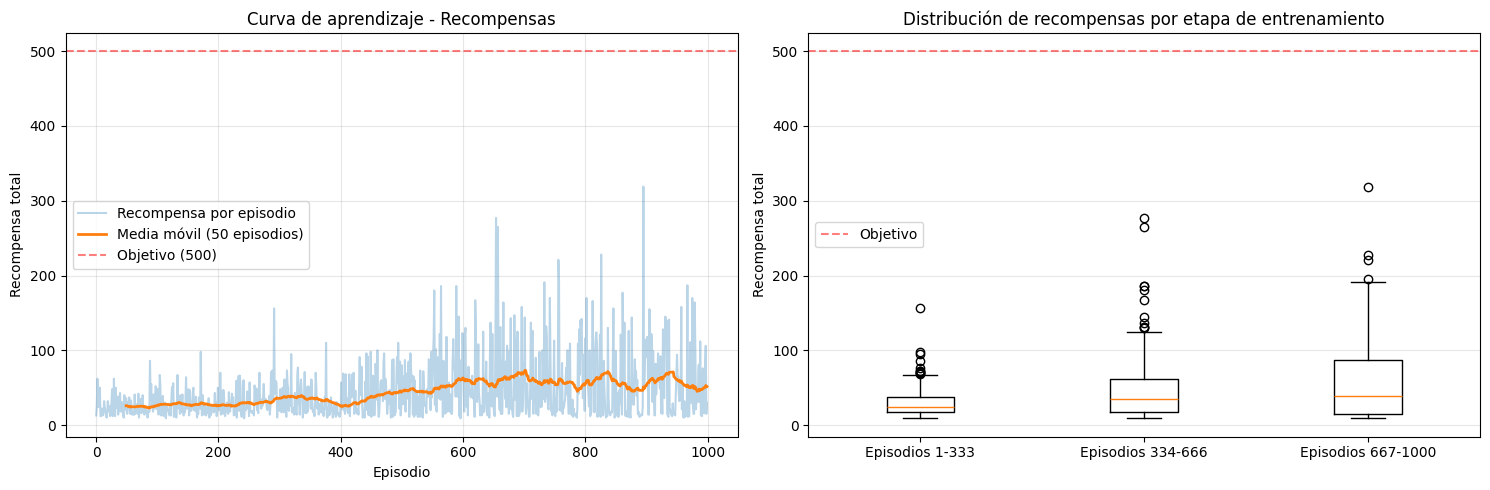


Estadísticas de entrenamiento:
  Recompensa promedio (últimos 100 episodios): 56.29
  Recompensa máxima alcanzada: 319.00
  Recompensa mínima: 9.00
  Desviación estándar (últimos 100): 46.09


In [58]:
# Calcular promedios móviles para suavizar las curvas
window_size = 50
rewards_moving_avg = np.convolve(rewards_base, np.ones(window_size)/window_size, mode='valid')

# Graficar resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Recompensas por episodio
axes[0].plot(rewards_base, alpha=0.3, label='Recompensa por episodio')
axes[0].plot(range(window_size-1, len(rewards_base)), rewards_moving_avg, 
             linewidth=2, label=f'Media móvil ({window_size} episodios)')
axes[0].axhline(y=500, color='r', linestyle='--', alpha=0.5, label='Objetivo (500)')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa total')
axes[0].set_title('Curva de aprendizaje - Recompensas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución de recompensas en diferentes etapas
early_rewards = rewards_base[:n_episodes_base//3]
mid_rewards = rewards_base[n_episodes_base//3:2*n_episodes_base//3]
late_rewards = rewards_base[2*n_episodes_base//3:]

axes[1].boxplot([early_rewards, mid_rewards, late_rewards], 
                labels=['Episodios 1-333', 'Episodios 334-666', 'Episodios 667-1000'])
axes[1].axhline(y=500, color='r', linestyle='--', alpha=0.5, label='Objetivo')
axes[1].set_ylabel('Recompensa total')
axes[1].set_title('Distribución de recompensas por etapa de entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticas finales
print("\nEstadísticas de entrenamiento:")
print(f"  Recompensa promedio (últimos 100 episodios): {np.mean(rewards_base[-100:]):.2f}")
print(f"  Recompensa máxima alcanzada: {np.max(rewards_base):.2f}")
print(f"  Recompensa mínima: {np.min(rewards_base):.2f}")
print(f"  Desviación estándar (últimos 100): {np.std(rewards_base[-100:]):.2f}")

## Evaluación del agente entrenado

Se evalúa el desempeño del agente entrenado ejecutando episodios sin exploración (política greedy pura).

In [59]:
def evaluate_agent(env, Q_table, discretize_fn, n_episodes=100):
    """
    Evalúa el desempeño de un agente entrenado.
    
    Args:
        env: Entorno de Gymnasium
        Q_table: Tabla Q del agente entrenado
        discretize_fn: Función para discretizar observaciones
        n_episodes: Número de episodios de evaluación
    
    Returns:
        eval_rewards: Lista de recompensas obtenidas
        eval_steps: Lista de pasos por episodio
    """
    eval_rewards = []
    eval_steps = []
    
    for episode in range(n_episodes):
        obs, _ = env.reset()
        state = discretize_fn(obs)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            # Usar política greedy (sin exploración)
            action = greedy_policy(state, Q_table)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = discretize_fn(obs)
            
            total_reward += reward
            steps += 1
        
        eval_rewards.append(total_reward)
        eval_steps.append(steps)
    
    return eval_rewards, eval_steps

Evaluando agente entrenado...

Resultados de evaluación (100 episodios sin exploración):
  Recompensa promedio: 93.73 ± 59.44
  Recompensa mediana: 106.00
  Recompensa máxima: 195.00
  Recompensa mínima: 14.00
  Episodios exitosos (>= 500): 0/100


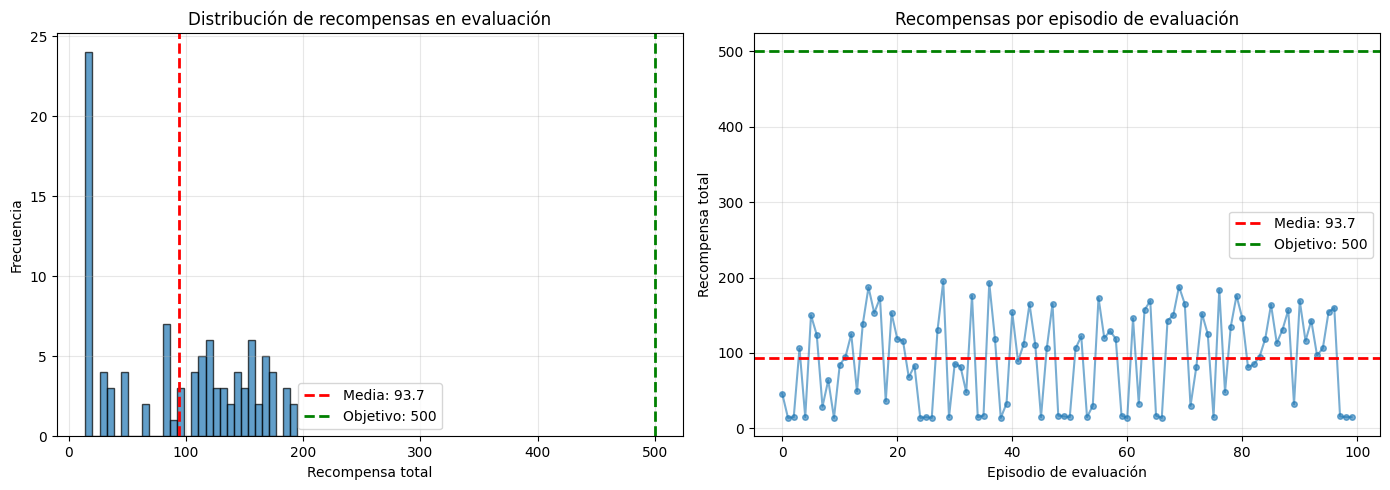

In [60]:
# Evaluar el agente entrenado
print("Evaluando agente entrenado...")
eval_rewards, eval_steps = evaluate_agent(env, Q_table_coarse, discretize_observation_coarse, n_episodes=100)

print("\nResultados de evaluación (100 episodios sin exploración):")
print(f"  Recompensa promedio: {np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}")
print(f"  Recompensa mediana: {np.median(eval_rewards):.2f}")
print(f"  Recompensa máxima: {np.max(eval_rewards):.2f}")
print(f"  Recompensa mínima: {np.min(eval_rewards):.2f}")
print(f"  Episodios exitosos (>= 500): {sum(r >= 500 for r in eval_rewards)}/100")

# Visualizar resultados de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eval_rewards, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(eval_rewards), color='r', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
axes[0].axvline(500, color='g', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[0].set_xlabel('Recompensa total')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de recompensas en evaluación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_rewards, marker='o', linestyle='-', alpha=0.6, markersize=4)
axes[1].axhline(np.mean(eval_rewards), color='r', linestyle='--', linewidth=2, label=f'Media: {np.mean(eval_rewards):.1f}')
axes[1].axhline(500, color='g', linestyle='--', linewidth=2, label='Objetivo: 500')
axes[1].set_xlabel('Episodio de evaluación')
axes[1].set_ylabel('Recompensa total')
axes[1].set_title('Recompensas por episodio de evaluación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()